<a href="https://colab.research.google.com/github/Lyanan85/In-GameSeries/blob/venv/vinhos_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [124]:
df=pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [125]:
df.shape

(1599, 12)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [127]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [128]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [129]:
df.duplicated().sum()

np.int64(240)

In [130]:
df_clean=df.copy()
df_clean=df_clean.drop_duplicates()
df_clean.shape

(1359, 12)

### Observa-se que a pontuação de qualidade dos vinhos varia de 3 a 8, sendo que não há registros com notas 9 ou 10. Isso indica que, no conjunto de dados analisado, não há amostras consideradas de qualidade máxima.

In [131]:
print(f"Todas as notas unicas na coluna qualidade: {df_clean['quality'].unique()}")
df_clean["quality"].value_counts().sort_index(ascending=False)

Todas as notas unicas na coluna qualidade: [5 6 7 4 8 3]


,count
quality,
8,17
7,167
6,535
5,577
4,53
3,10


### Foi realizada uma análise agrupando os dados pela variável quality com o objetivo de observar como os atributos açúcar residual (residual sugar) e teor alcoólico (alcohol) se comportam em diferentes níveis de avaliação sensorial dos vinhos.

Os resultados médios por nota de qualidade foram:

In [132]:
dfsugar_alcohol=df_clean.groupby("quality")[["residual sugar","alcohol"]].mean().reset_index()
dfsugar_alcohol

,quality,residual sugar,alcohol
0,3,2.635000,9.955000
1,4,2.694340,10.265094
2,5,2.509532,9.888562
3,6,2.457290,10.658879
4,7,2.716766,11.491118
5,8,2.576471,12.158824


### A partir desses dados, é possível observar uma tendência clara de aumento do teor alcoólico à medida que a qualidade do vinho aumenta. Isso sugere que vinhos considerados de melhor qualidade costumam ter maior concentração alcoólica, o que pode estar associado a maior corpo, estrutura e complexidade – características valorizadas em avaliações sensoriais.

Já o açúcar residual apresentou variações mais sutis entre os diferentes níveis de qualidade, sem uma tendência linear clara. Isso indica que o açúcar, nesse conjunto de dados, não é um fator determinante isolado na avaliação da qualidade dos vinhos tintos analisados.

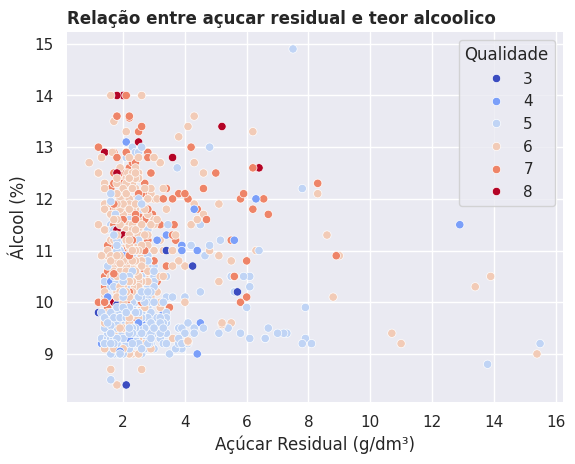

In [133]:
sns.set(style="darkgrid")
sns.scatterplot(data=df_clean,x="residual sugar",y="alcohol",hue="quality",palette="coolwarm")
sns.despine(left=True,bottom=True)
plt.title("Relação entre açucar residual e teor alcoolico",fontsize=12,loc="Left",fontweight="bold")
plt.xlabel('Açúcar Residual (g/dm³)')
plt.ylabel('Álcool (%)')
plt.legend(title='Qualidade')
plt.show()


### Versão Interativa do Gráfico Anterior

Abaixo está a versão interativa do gráfico de dispersão entre açúcar residual e teor alcoólico, agora utilizando a biblioteca plotly. Esse gráfico permite uma exploração mais dinâmica dos dados, possibilitando interações como zoom, destaque e visualização individual de cada ponto ao passar o mouse. A codificação por cor e tamanho segue a mesma lógica anterior, representando os diferentes níveis de qualidade dos vinhos.



In [134]:
fig=px.scatter(
    df_clean,
    x="residual sugar",
    y="alcohol",
    color="quality",
    size="quality",
    hover_name="quality",
    title="Relação entre Açucar Residual e Teor Alcoólico",
    template="plotly_dark",
    labels={
        "residual sugar":"Açúcar Residual (g/dm³)",
        "alcohol":"Álcool(%)",
        "quality":"Qualidade"
    }

)
fig.show()

### Foram gerados dois boxplots para análise da distribuição do teor alcoólico e do açúcar residual com base na qualidade dos vinhos.

No gráfico de teor alcoólico, observa-se uma alta concentração de outliers na qualidade 5, além de um outlier isolado na qualidade 6. Nas notas mais altas (7 e 8), os dados tendem a ser mais homogêneos, com menos valores extremos, sugerindo um padrão mais consistente entre os vinhos de melhor avaliação.

Já no gráfico de açúcar residual, os outliers estão distribuídos entre várias faixas de qualidade, especialmente nas qualidades 5, 6 e 7. Isso indica que esse atributo apresenta maior variabilidade entre vinhos de mesma nota, o que pode refletir diferentes estilos de produção ou perfis sensoriais não necessariamente capturados pela nota final de qualidade.

A identificação desses valores extremos é relevante para análises futuras, pois podem influenciar resultados estatísticos e modelos preditivos.

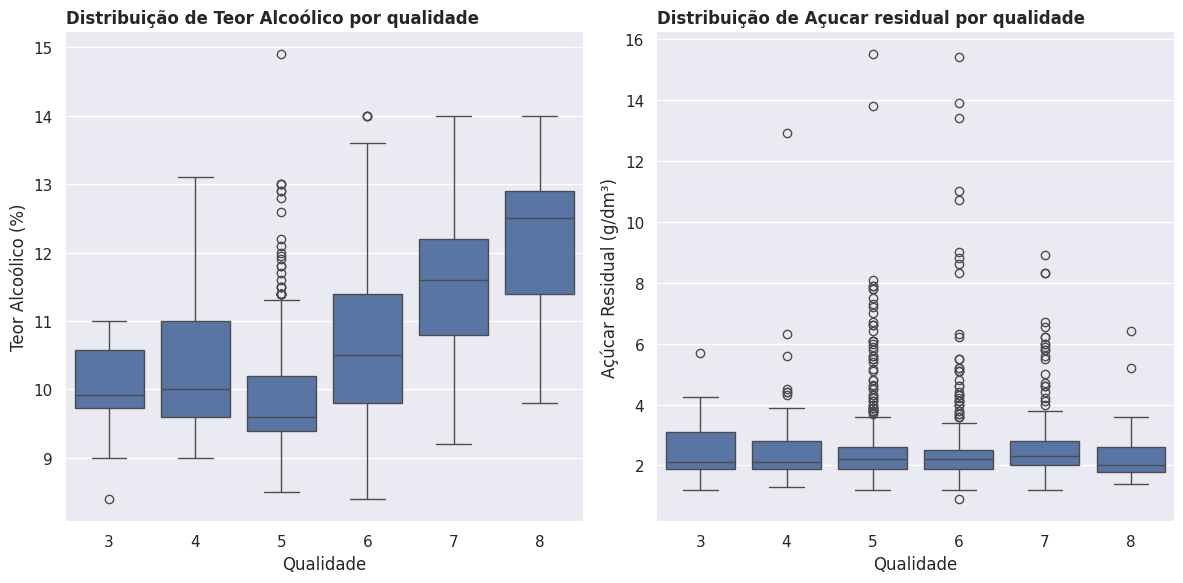

In [135]:
fig,ax=plt.subplots(1,2,figsize=(12,6))
sns.boxplot(data=df_clean, x='quality', y='alcohol',ax=ax[0])
ax[0].set_title("Distribuição de Teor Alcoólico por qualidade",fontsize=12,fontweight="bold",loc="left")
ax[0].set_xlabel("Qualidade")
ax[0].set_ylabel("Teor Alcoólico (%)")

sns.boxplot(data=df_clean,x='quality',y='residual sugar',ax=ax[1])
ax[1].set_title("Distribuição de Açucar residual por qualidade",fontsize=12,fontweight="bold",loc="left")
ax[1].set_xlabel("Qualidade")
ax[1].set_ylabel("Açúcar Residual (g/dm³)")

sns.despine(left=True,bottom=True)
plt.tight_layout()
plt.show()

### Identificando Outliers da coluna açucar residual

In [136]:
dfsugar_alcohol.describe()

,quality,residual sugar,alcohol
count,6.000000,6.000000,6.000000
mean,5.500000,2.598233,10.736246
std,1.870829,0.102806,0.911092
min,3.000000,2.457290,9.888562
25%,4.250000,2.526267,10.032524
50%,5.500000,2.605735,10.461986
75%,6.750000,2.679505,11.283058
max,8.000000,2.716766,12.158824


In [137]:
def outlier_remove(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return (df[col] >= limite_inferior) & (df[col] <= limite_superior)


### Combinando os outliers para remove-los do DataSet

In [151]:
# Booleanos com base no df_clean
mask_sugar = outlier_remove(df_clean, "residual sugar")
mask_alcohol = outlier_remove(df_clean, "alcohol")

# Combinar: só manter os que são válidos em ambos
mask_valido = mask_sugar & mask_alcohol

# Agora crie df_sem_out corretamente
df_sem_out = df_clean[mask_valido].copy()

# Confirmar que os outliers foram removidos corretamente:
print("Antes:", df_clean.shape[0])
print("Depois:", df_sem_out.shape[0])
print("Total de outliers removidos:", df_clean.shape[0] - df_sem_out.shape[0])

# Agora isso deve estar certo:
  print(df_sem_out[~mask_valido])  # Isso deve retornar DataFrame vazio


Antes: 1359
Depois: 1223
Total de outliers removidos: 136
Empty DataFrame
Columns: [fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, quality]
Index: []


<ipython-input-151-fab2177cf9a5>:17: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



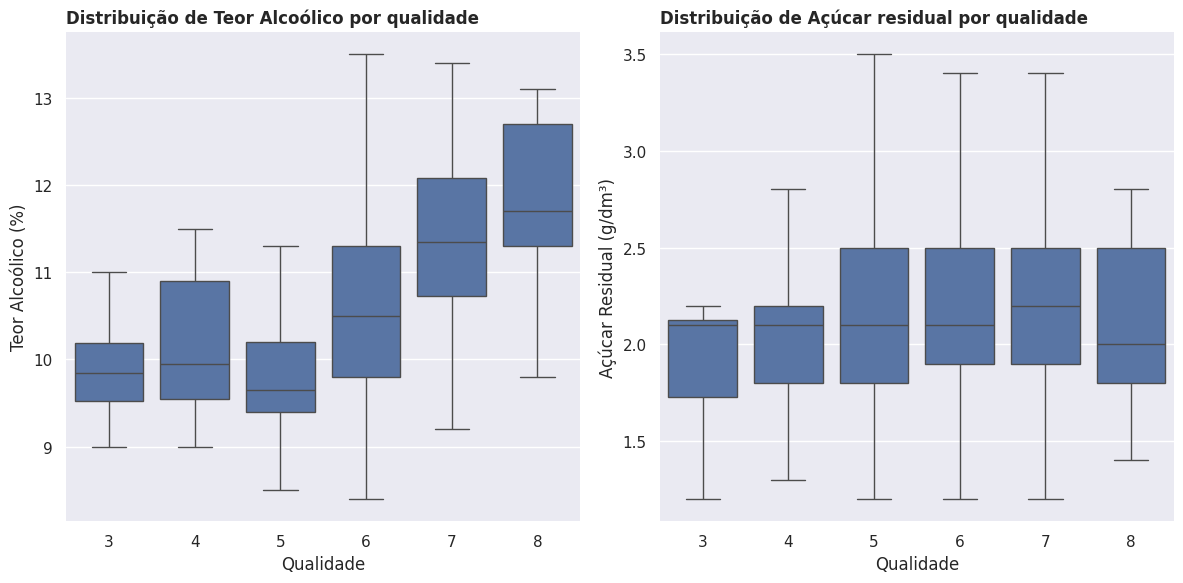

In [158]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=df_sem_out, x='quality', y='alcohol', ax=ax[0], showfliers=False)
ax[0].set_title("Distribuição de Teor Alcoólico por qualidade", fontsize=12, fontweight="bold", loc="left")
ax[0].set_xlabel("Qualidade")
ax[0].set_ylabel("Teor Alcoólico (%)")

sns.boxplot(data=df_sem_out, x='quality', y='residual sugar', ax=ax[1], showfliers=False)
ax[1].set_title("Distribuição de Açúcar residual por qualidade", fontsize=12, fontweight="bold", loc="left")
ax[1].set_xlabel("Qualidade")
ax[1].set_ylabel("Açúcar Residual (g/dm³)")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


In [153]:
def categorize_wine(quality):
    if quality<=5:
        return "Baixa-Qualidade"
    if quality>=7:
        return "Alta-Qualidade"
    else:
      return "Média-Qualidade"


In [154]:
df_sem_out["Categoria"]=df_sem_out["quality"].apply(categorize_wine)
df_sem_out.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Categoria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Baixa-Qualidade
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Baixa-Qualidade
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Baixa-Qualidade
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Média-Qualidade
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Baixa-Qualidade


In [155]:
df_categorias=df_sem_out.groupby("Categoria")[["residual sugar","pH","alcohol","quality"]].mean()
df_categorias

,residual sugar,pH,alcohol,quality
Categoria,,,,
Alta-Qualidade,2.232781,3.285762,11.406291,7.086093
Baixa-Qualidade,2.180469,3.311198,9.891493,4.895833
Média-Qualidade,2.188609,3.317843,10.614617,6.000000


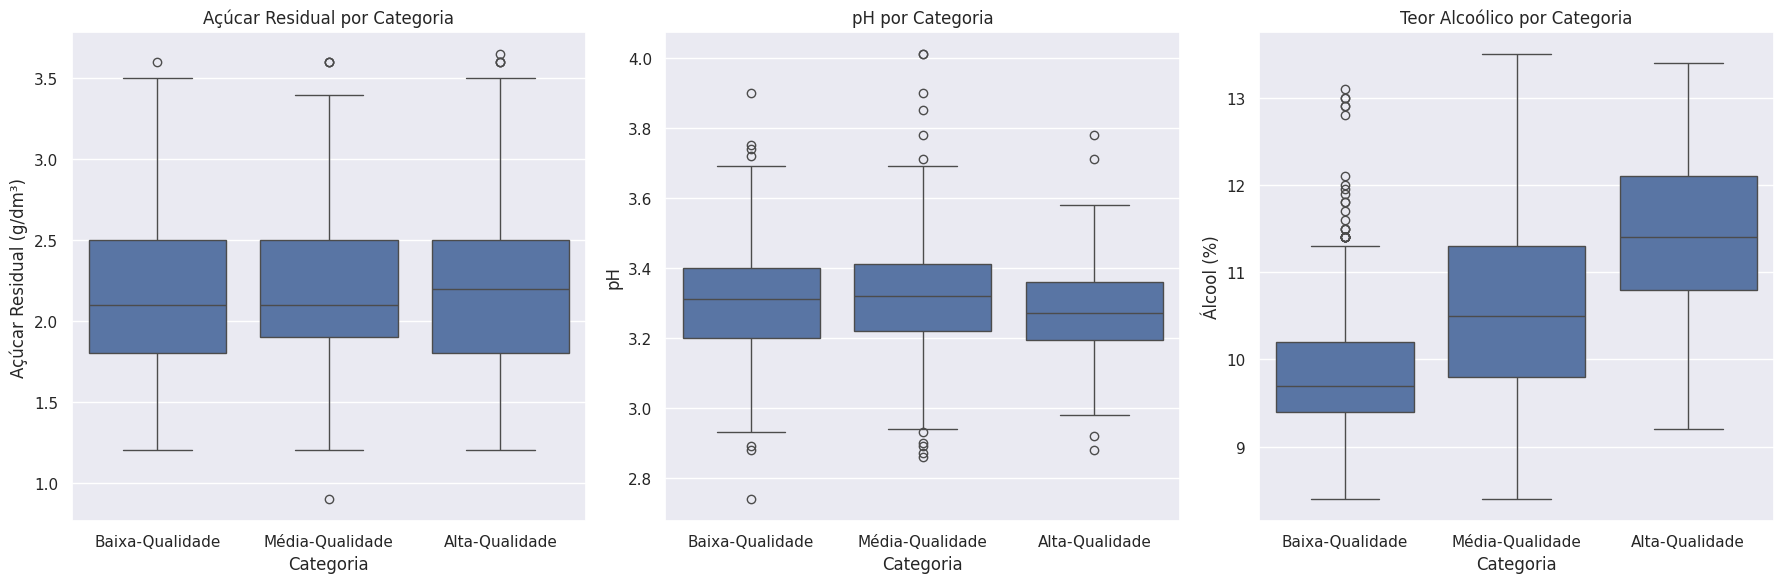

In [156]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df_sem_out, x='Categoria', y='residual sugar', ax=ax[0])
ax[0].set_title("Açúcar Residual por Categoria")
ax[0].set_ylabel("Açúcar Residual (g/dm³)")

sns.boxplot(data=df_sem_out, x='Categoria', y='pH', ax=ax[1])
ax[1].set_title("pH por Categoria")
ax[1].set_ylabel("pH")

sns.boxplot(data=df_sem_out, x='Categoria', y='alcohol', ax=ax[2])
ax[2].set_title("Teor Alcoólico por Categoria")
ax[2].set_ylabel("Álcool (%)")

plt.tight_layout()
plt.show()
